In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import gc
import warnings
warnings.filterwarnings("ignore")

In [27]:
calender=pd.read_csv(r"Data\calendar.csv")

In [28]:
sellprices=pd.read_csv(r"Data/sell_prices.csv")

In [29]:
sales=pd.read_csv(r"Data\sales_train_validation.csv")

In [30]:
def save_mem(sales, verbose=True):
    print("BEFORE ",sales.memory_usage(deep=True).sum() / 1024**2, "MB")
    for i in sales.columns:
        if sales[i].dtype=="int64":
            sales[i]=pd.to_numeric(sales[i],downcast="integer")
        elif sales[i].dtype=="float64":
            sales[i]=pd.to_numeric(sales[i],downcast="float")
        elif sales[i].dtype=='object':
                if i=="sales":
                     continue
                # convert to category IF it has repeated/limited values
                num_unique = sales[i].nunique()
                num_total = len(sales[i])
                if num_unique / num_total < 0.5:  # heuristic: repeats a lot
                    sales[i] = sales[i].astype('category')
            
    gc.collect()
    print("AFTER ",sales.memory_usage(deep=True).sum() / 1024**2, "MB")
    return sales

In [31]:
print("Total No.of Items across all stores ",len(sales["item_id"].unique()))

Total No.of Items across all stores  3049


In [32]:
print("Categories across all the stores ",sales["cat_id"].unique())

Categories across all the stores  ['HOBBIES' 'HOUSEHOLD' 'FOODS']


In [33]:
print("Total No.of Stores ",len(sales["store_id"].unique()))
print(sales["store_id"].unique())

Total No.of Stores  10
['CA_1' 'CA_2' 'CA_3' 'CA_4' 'TX_1' 'TX_2' 'TX_3' 'WI_1' 'WI_2' 'WI_3']


In [34]:
items_store={}
for i in sales["store_id"].unique():
    items_store[i]=len(sales[sales["store_id"]==i]["item_id"].unique())
items_store

{'CA_1': 3049,
 'CA_2': 3049,
 'CA_3': 3049,
 'CA_4': 3049,
 'TX_1': 3049,
 'TX_2': 3049,
 'TX_3': 3049,
 'WI_1': 3049,
 'WI_2': 3049,
 'WI_3': 3049}

In [35]:
items_category={}
for i in sales["cat_id"].unique():
    items_category[i]=len(sales[sales["cat_id"]==i]["item_id"].unique())
items_category

{'HOBBIES': 565, 'HOUSEHOLD': 1047, 'FOODS': 1437}

In [36]:
for i in items_store:
    if items_store[i]==items_store["CA_1"]:
        print("ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN ",i)
    else:
        print("ITEMS ARE DIFFRENT IN STORE CA1 AND ",i)

ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_3
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_4
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_3
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_3


In [37]:
calender.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [38]:
calender.drop("weekday",axis=1,inplace=True)

In [39]:
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].isnull().sum()

event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

In [40]:
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]]=calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].fillna("None")
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].isnull().sum()

event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
dtype: int64

In [41]:
dupes = sellprices.duplicated(subset=['store_id','item_id','wm_yr_wk']).sum()
print(dupes)# CHECKS WETHER WITHIN A WEEK A PRICE CHANGE HAD OCCURED
dupes = calender.duplicated(subset=["date"]).sum()
print(dupes)
del dupes,items_category,items_store
gc.collect()

0
0


1564

In [42]:
sales=sales.melt(id_vars=["item_id","dept_id","cat_id","store_id","state_id"],var_name="Date",value_name="sales")
sales=save_mem(sales)

BEFORE  20573.97554588318 MB
AFTER  2450.4141006469727 MB


In [43]:
sales=pd.merge(sales,calender,left_on=["Date"],right_on=["d"])
sales.drop(["d","date"],inplace=True,axis=1)
sales=save_mem(sales)
del calender
gc.collect()

BEFORE  20325.060061454773 MB
AFTER  3171.0538568496704 MB


0

In [44]:
sales_sorted = sellprices.sort_values(['item_id', 'store_id', 'wm_yr_wk']) 
newlaunch_sorted = (sales_sorted["sell_price"].notna().groupby([sales_sorted["item_id"], sales_sorted["store_id"]]).cumsum() > 0)
print(len(sales_sorted[newlaunch_sorted]))
print(len(sales_sorted[sales_sorted["sell_price"].notna()])) 
### USED TO FID WHETHER ANY PRODUCT HAD NAN VALUES IN BETWEEN THE TRAINING DATA BUT NON FOUND AS CUSUM AND NOTNA PRODUCES SALES LENGTH
del sales_sorted,newlaunch_sorted
gc.collect()

6841121
6841121


0

In [45]:
gc.collect()
sales=pd.merge(sellprices,sales,on=["item_id","store_id","wm_yr_wk"],how="right")
# WHY HOW=right JOINS EVERY SALES ROW IF EVEN A PRICE IS MISSING AT THAT POINT THE PRODUCTS
#  WHICH ARE NOT AVAILABLE DURING TAHT TIME IS RECOREDED AS NAN
## THE INDEX CANT BE THE DATE COLUMN AS THE DATE IN THE ABOVE SALES DATA GETS REPEATED
del sellprices
gc.collect()
sales=save_mem(sales)

BEFORE  10165.369999885559 MB
AFTER  3393.555115699768 MB


In [46]:
print("Total rows before filtering:", len(sales))
print("Rows with missing sell_price (pre-launch):", sales['sell_price'].isnull().sum())

Total rows before filtering: 58327370
Rows with missing sell_price (pre-launch): 12299413


In [47]:
##MEANING THERE IS NO MID RANGE NA VALUES IN THE DATASET

In [48]:
## DROPPING THE ROWS WHERE THE PRODUCTS IS NOT RELEASED
sales=sales[sales["sell_price"].notna()]
gc.collect()

0

In [49]:
print("NO.of ITEM ",len(sales["item_id"].unique()))
print("NO.of DEPARTMENT",len(sales["dept_id"].unique()))
print("NO.OF CATEGORIES",len(sales["cat_id"].unique()))

NO.of ITEM  3049
NO.of DEPARTMENT 7
NO.OF CATEGORIES 3


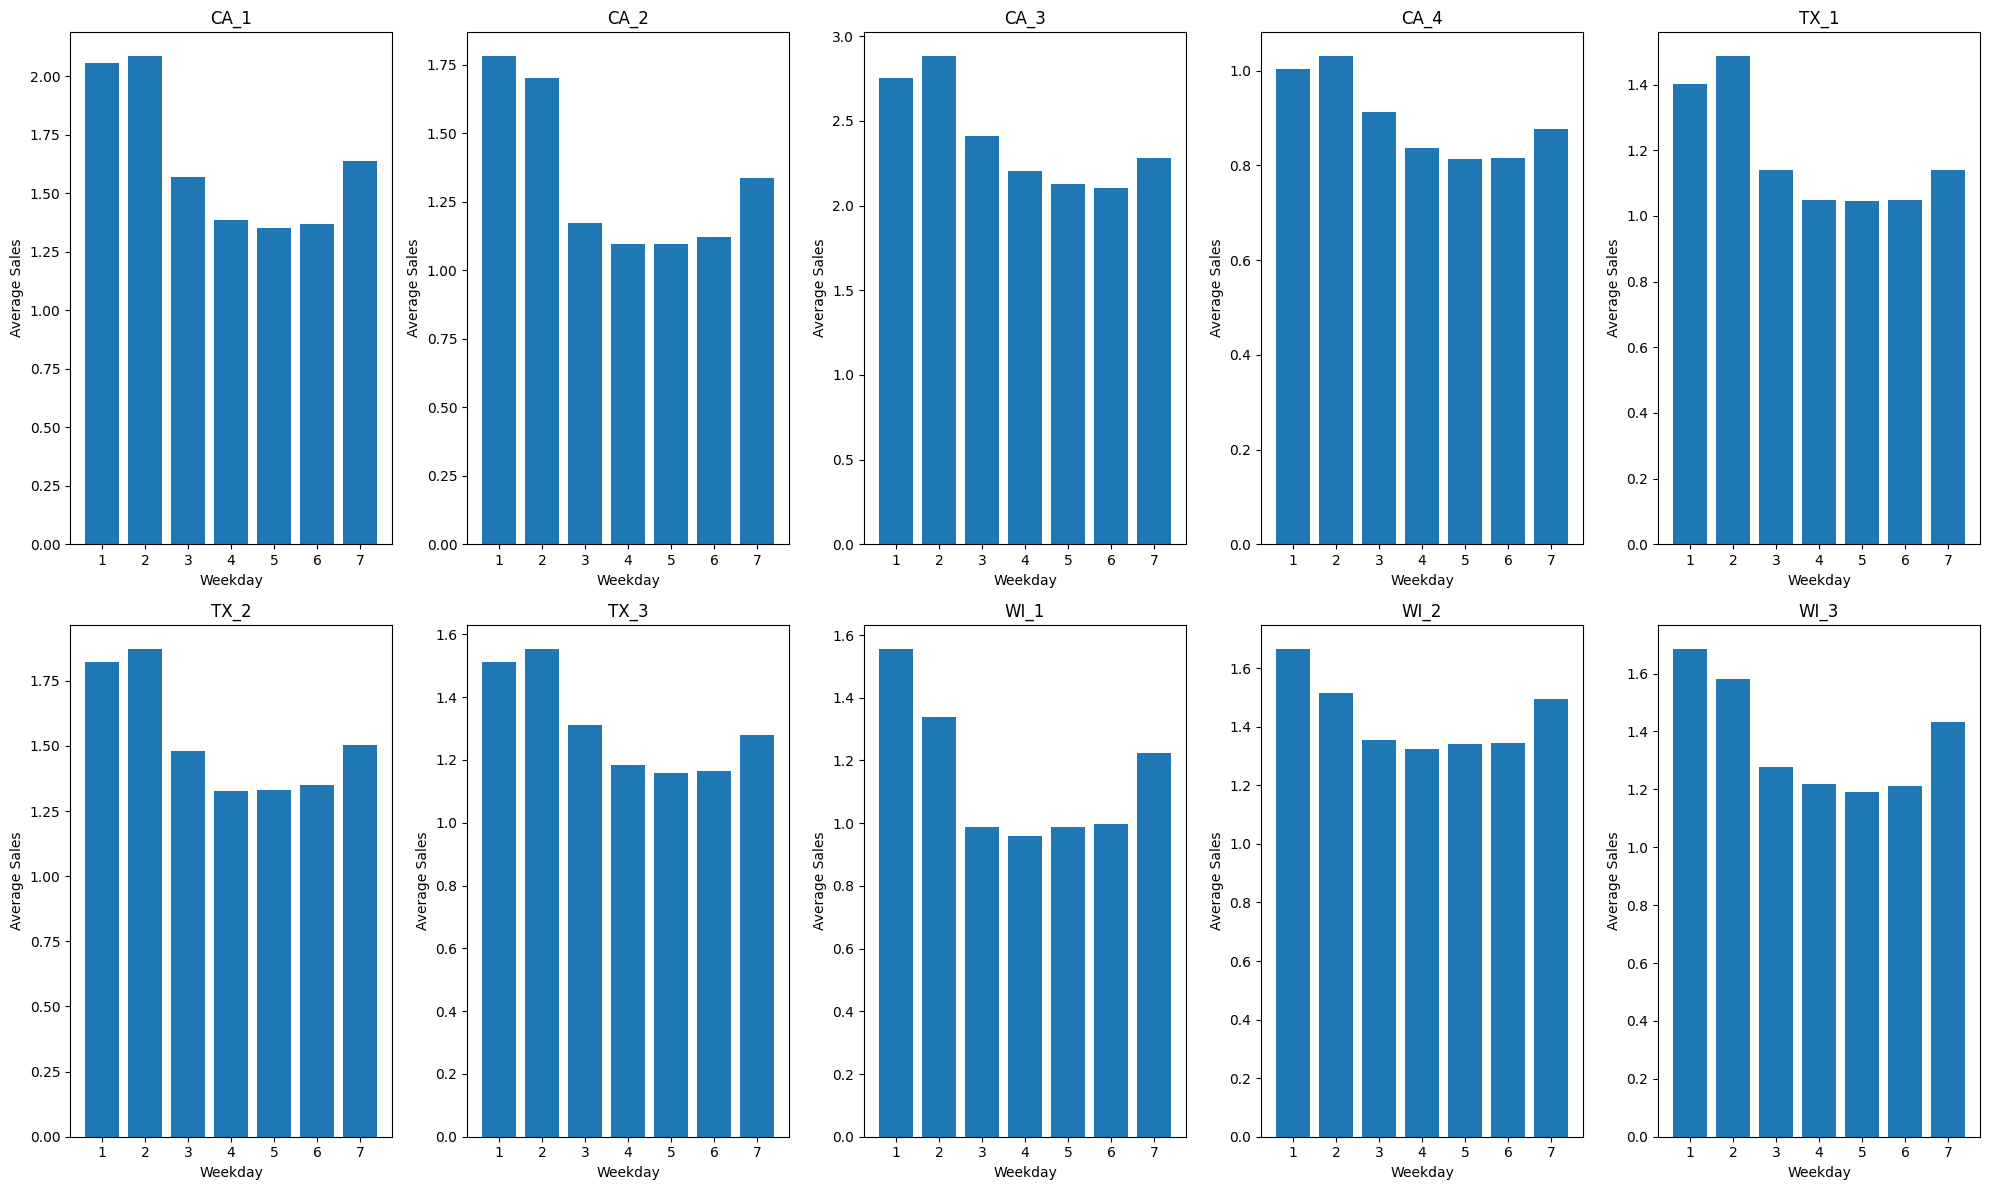

In [50]:
weekdays = sales.groupby(["wday", "store_id"])["sales"].mean().unstack()
fig, axes = plt.subplots(2, 5, figsize=(20, 12))
axes = axes.flatten()
for ax, store in zip(axes, weekdays.columns):
    ax.bar(weekdays.index, weekdays[store])
    ax.set_title(store)
    ax.set_xlabel("Weekday")
    ax.set_ylabel("Average Sales")
    ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()
### IN THE BELOW GRAPHS WE CAN EEVENTLY VIULIZE THAT THE WEEKLY SALES TREND IS SIMILAR ACROSS ALL THE STORES 
### SO LETS HAVE SAME ENCODING FOR ALL THE STORES
del weekdays

In [51]:
for k in sales["year"].unique():
    print(k)
    for column in ["event_name_1","event_type_2"]:
        count = ((sales["year"] == k) & (sales[column]!="None") & (sales["store_id"]=="CA_1") & (sales["item_id"]=="HOBBIES_1_008")).sum()
        print(f"{column}  {count}" )
del count

2011
event_name_1  26
event_type_2  1
2012
event_name_1  30
event_type_2  0
2013
event_name_1  29
event_type_2  1
2014
event_name_1  28
event_type_2  2
2015
event_name_1  30
event_type_2  0
2016
event_name_1  11
event_type_2  0


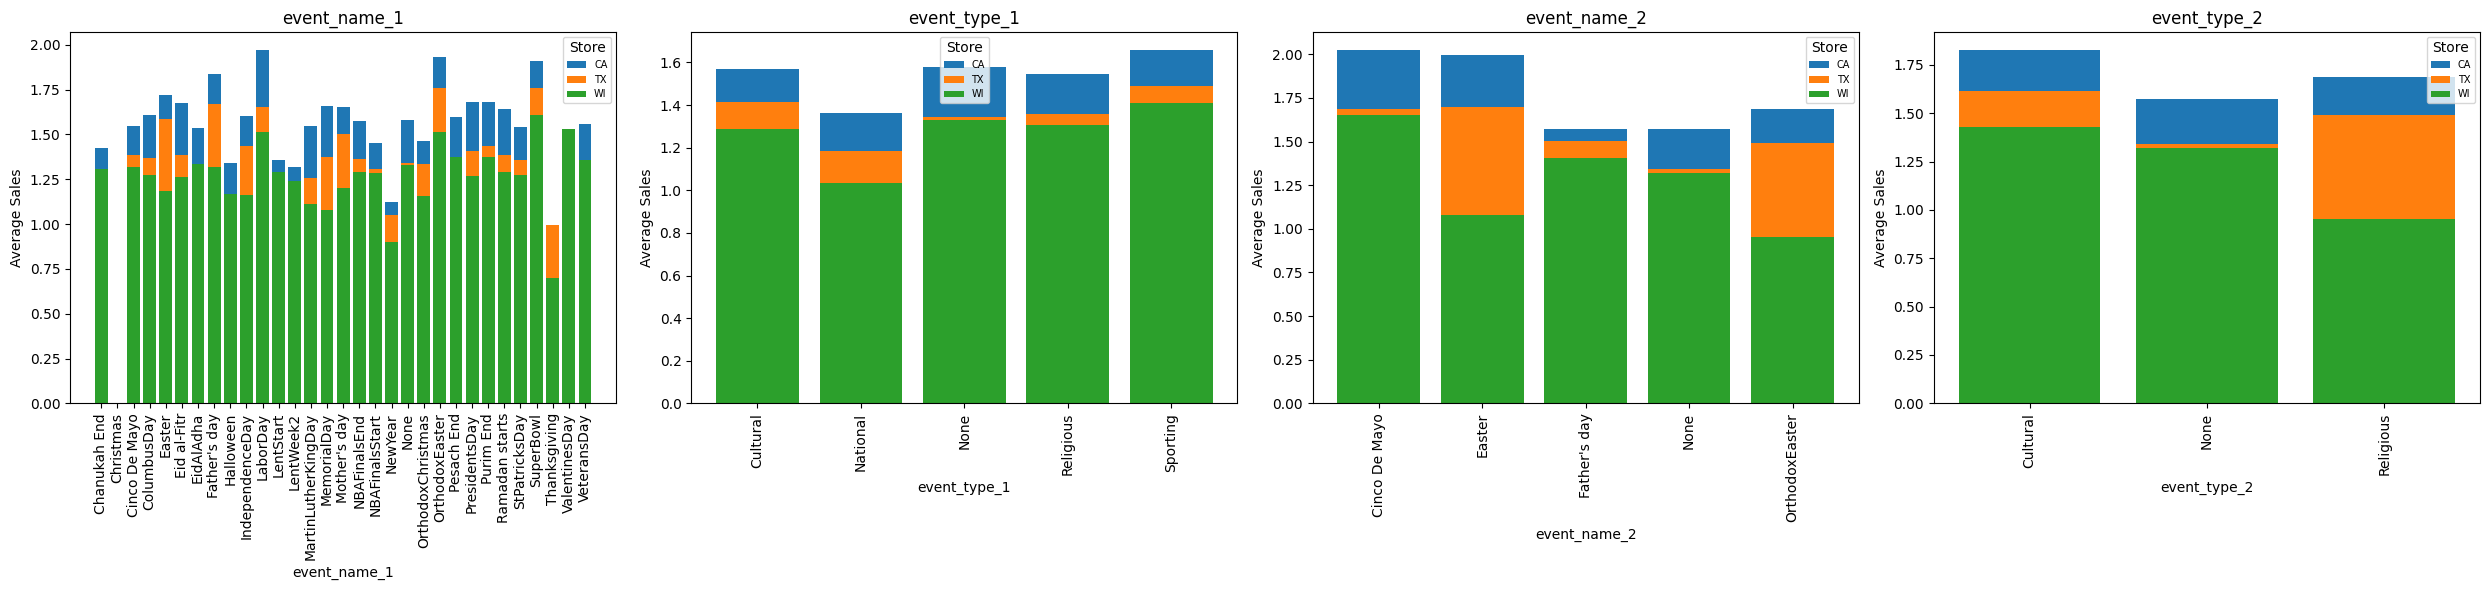

35504

In [52]:
events = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
fig, axes = plt.subplots(1, 4, figsize=(25, 6))
for ax, i in zip(axes, events):
    x = sales.groupby([i,"state_id"])["sales"].mean().unstack()
    for j in x.columns:
        ax.bar(x.index, x[j], label=j)
    ax.set_title(i)
    ax.set_xlabel(i)
    ax.set_ylabel("Average Sales")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Store", fontsize=7)
plt.tight_layout()
plt.show()
del fig,axes
gc.collect()

In [53]:
### WHEN WE USE THE EVENT NAME 1 AS THE NO.OF OCCURANCES OF THE EVENTS IS LESS WE HAVE INSUFFICENT DATA SO LETS USE THE EVENT TYPE
### NOTE THAT EVEN THOUGH THE EVENT NAME 2 PROVIDES HUGE SPIKE IT MOSTLY COULD BE AN NOICE  IN TOTAL OF 5 YEARS WE HAVE HARDLY 5 DAYS OF EVENT 2 IS PRESENT

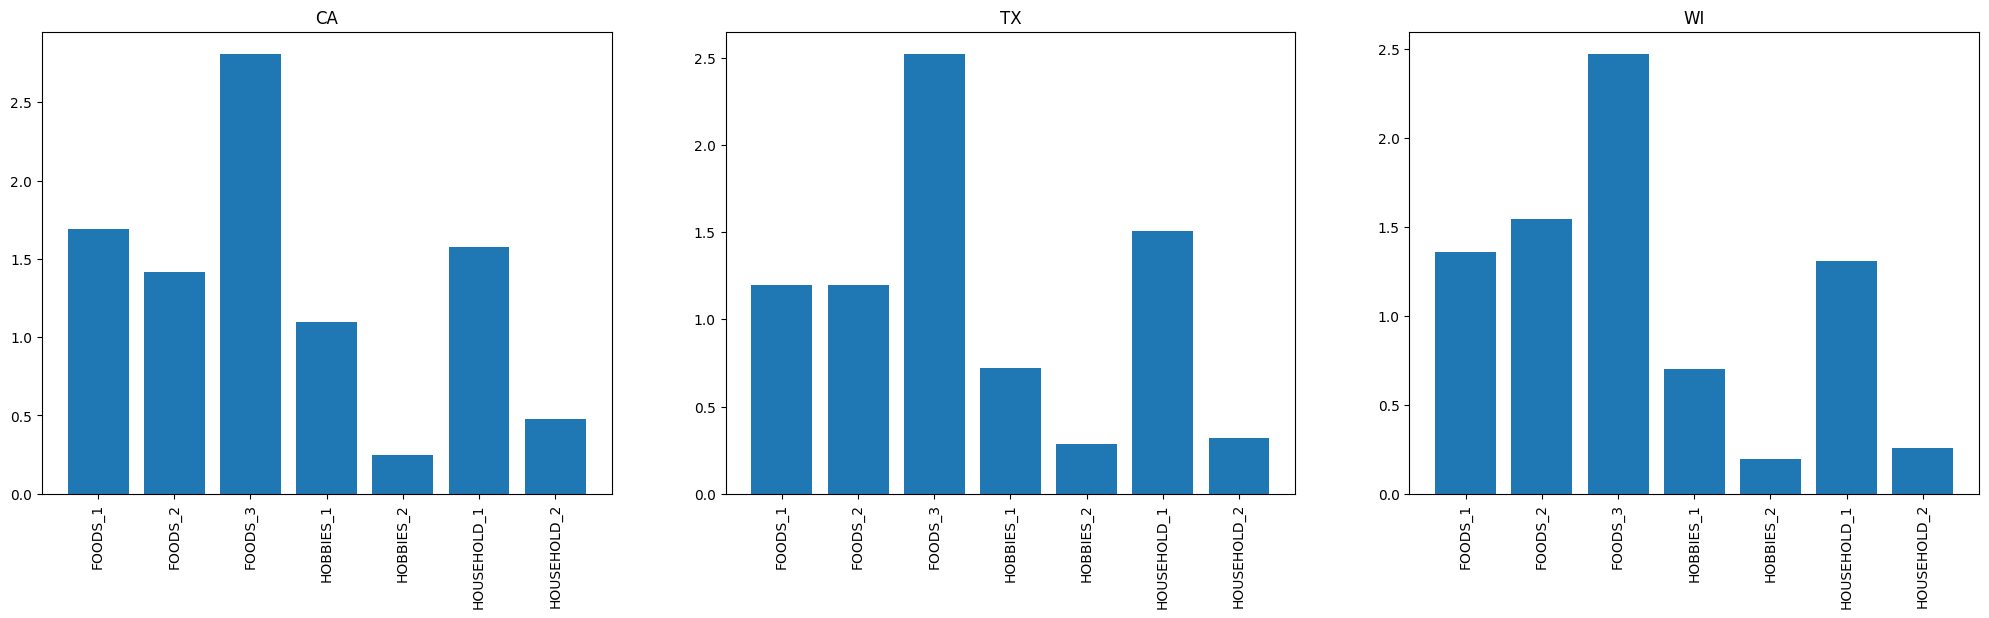

240

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))
x = sales.groupby(["dept_id","state_id"])["sales"].mean().unstack().reset_index()
for i,j in zip(sales["state_id"].unique(),axes):
    j.bar(x["dept_id"].values,x[i].values)
    j.tick_params(axis="x",rotation=90)
    j.set_title(i)
plt.show()
del fig,axes
gc.collect()

In [55]:
## ALL THE STATES HAVE SIMILAR DEPARTMENT SALES AND HIGHER SALES IS FOUND IN THE FOOD_3 CATEGORY WITH LEAST IN HOBBIES_2 AND HOUSEHOLD_2 
# SO LETS DO MEAN ENCODING FOR THE FEATURE DEPT_ID WITH MEAN ENCODING 
# LABEL ENCODING WITH ORDER IS SIMILAR TO MEAN ENCODING IN TREE BASED MODELS


<BarContainer object of 10 artists>

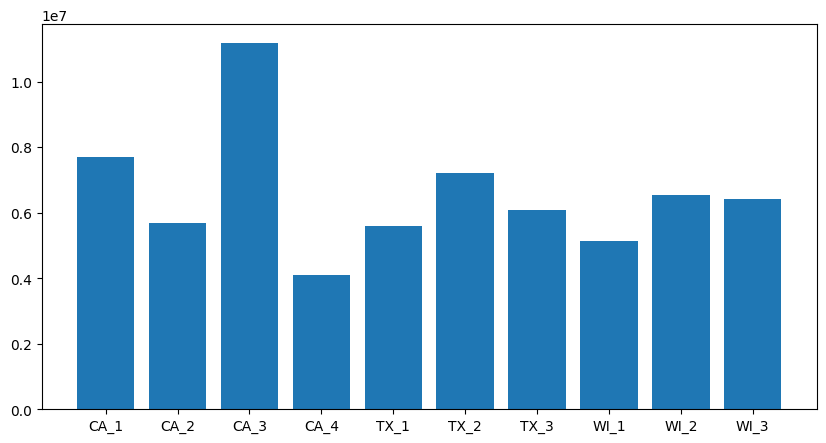

In [56]:
store_sales = sales.groupby("store_id")["sales"].sum()
plt.figure(figsize=(10,5))
plt.bar(store_sales.index,store_sales.values)

In [57]:
### THE SALES IS FOUND TO BE HIGHEST IN THE CA_3 STORE ANND LOWEST CA_4 STORE

In [58]:

"""
.mean() shrinks your data down to one row per group.

.transform("mean") keeps your data the exact same size, broadcasting the group's answer back to every individual row"""

'\n.mean() shrinks your data down to one row per group.\n\n.transform("mean") keeps your data the exact same size, broadcasting the group\'s answer back to every individual row'

10106

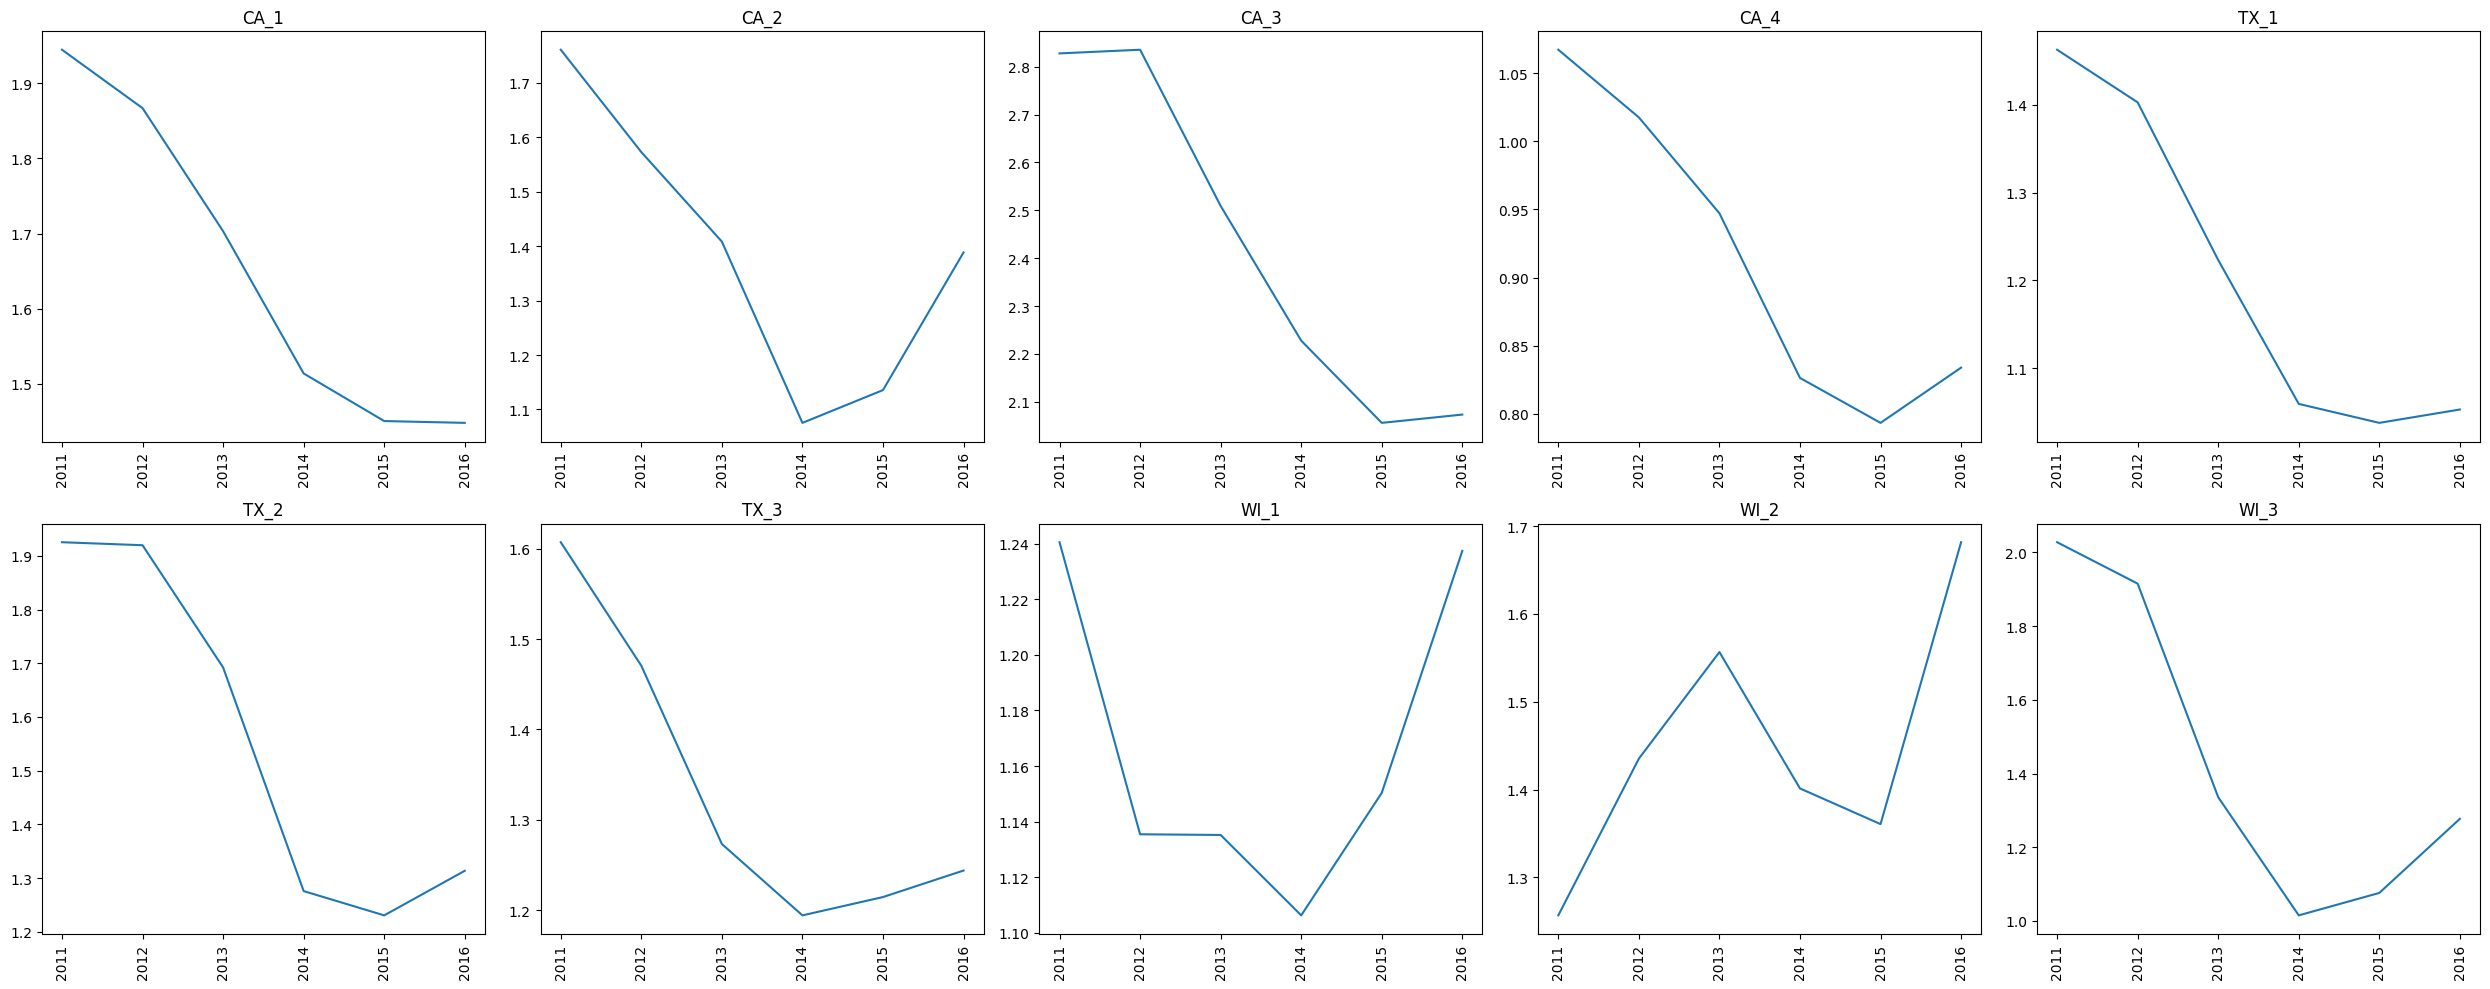

In [59]:
x=sales.groupby(["year","store_id"])["sales"].mean().unstack().reset_index()
fig,axes=plt.subplots(2,5,figsize=(25,10))
axes=axes.flatten()
for i,j in zip(sales["store_id"].unique(),axes):
    j.plot(x["year"].values,x[i].values)
    j.set_title(i)
    j.tick_params(axis="x",rotation=90)
plt.tight_layout()
del fig,axes
gc.collect()

In [60]:
## THE TREND IN THE DIFF STORES ACROSS YEARS IS CHANGING 
### THE YEAR DOES NOT EVEN SHOW SIMILAR BEHEVIOUR ACROSS THE STATE ITSELF
### THE YEAR TO BE ENCODED TO BE PROCESSED DIFF FOR EACH STORE AND LETS LEAVE IT TO THE MODEL AS WE ARE GOING TO USE ANY TREE MODEL 
### AND TREE MOEL WILL EVENTUALLY FIND A BEST SPLIT CROSS YEARS

31978

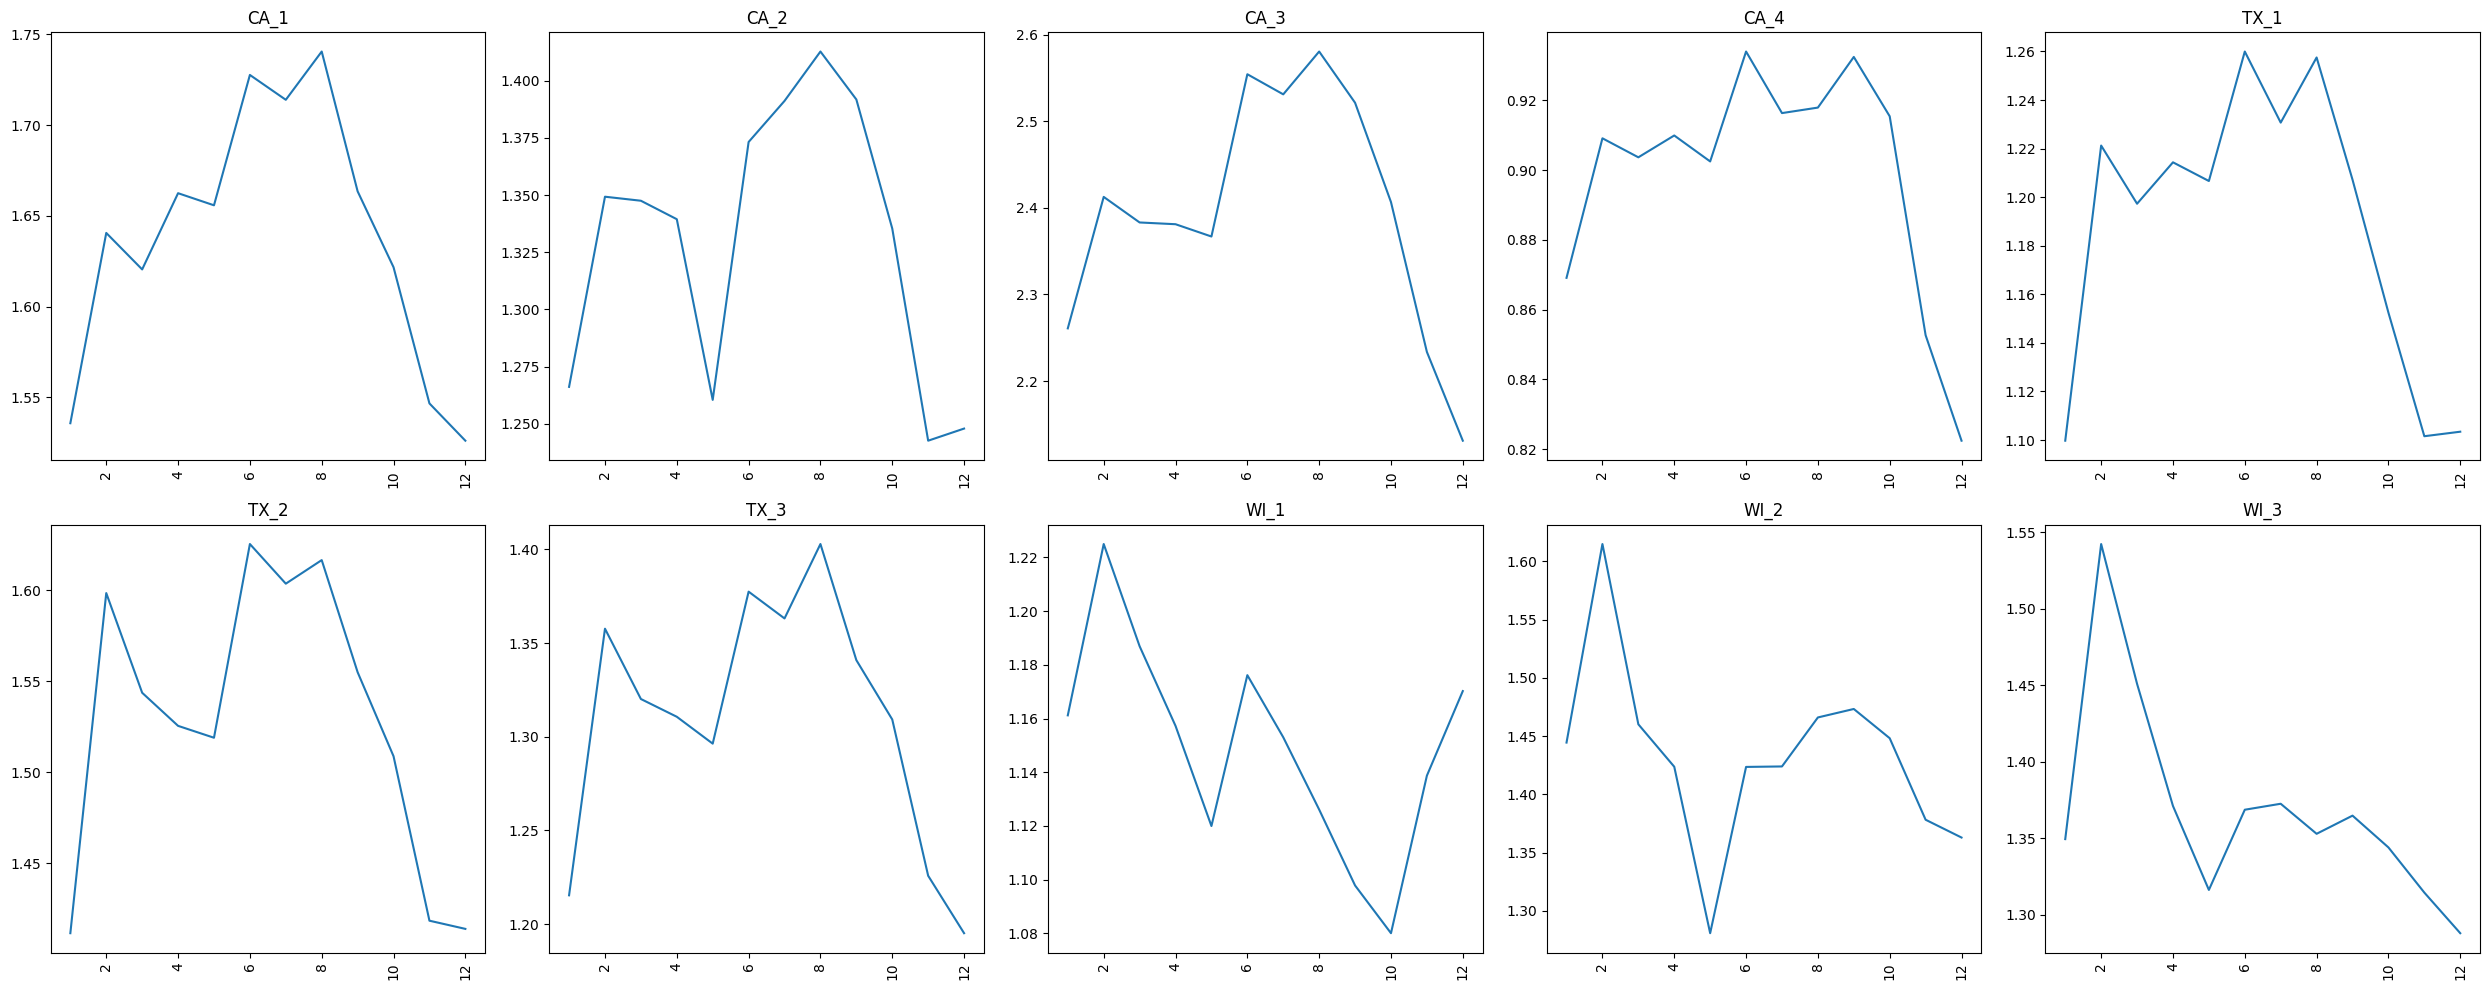

In [61]:
x=sales.groupby(["month","store_id"])["sales"].mean().unstack().reset_index()
fig,axes=plt.subplots(2,5,figsize=(25,10))
axes=axes.flatten()
for i,j in zip(sales["store_id"].unique(),axes):
    j.plot(x["month"].values,x[i].values)
    j.set_title(i)
    j.tick_params(axis="x",rotation=90)
plt.tight_layout()
del fig,axes,x
gc.collect()


In [62]:
### THE MONTH FEATURES SHOWS A CLEAR TREND ACROSS SALES IN DIFF MONTHS IN DIFF STORES
### THE MONTHLY SALES TREND IS ALMOST SIMILAR WITHIN THE STATE AND LETS LEAVE THIS ALSO TO MODEL BU THE TREND OF WI_1 IS OUT FOR IT 
## LETS LEAVE THIS ALSO AS THE SAME
## I DID NOT DO ANY ENCODING BCZ WE CANT GLOBALLY FIND A TREND ACROSS ALL THE SALES VALUES AND LET THE MODEL FIGURE IT 
## I DID THE WEEK_ENC AS THE GLOBALL TREND IS SAME ACROSS ALL THE STORES AND LETS US TO EASILY ENC 

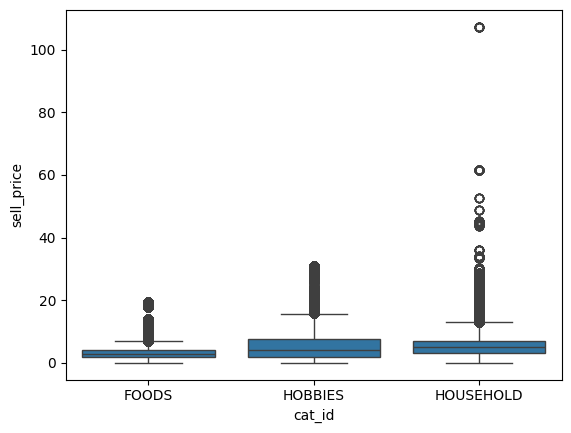

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=sales, x="cat_id", y="sell_price")
plt.show()
### WHY BOX PLOT IS THAT ITS EASY TO VIEW THE CLEAR DIFF IN THE SELL PRICES BASED ON ITEM ACROSS ALL THE STORES ACROSS AL THE WEEKS
### THIS PLOT SUGGEST THAT THERE IS AN RIGHT SKEWWED IN THE SELL PRICE DATA

1427

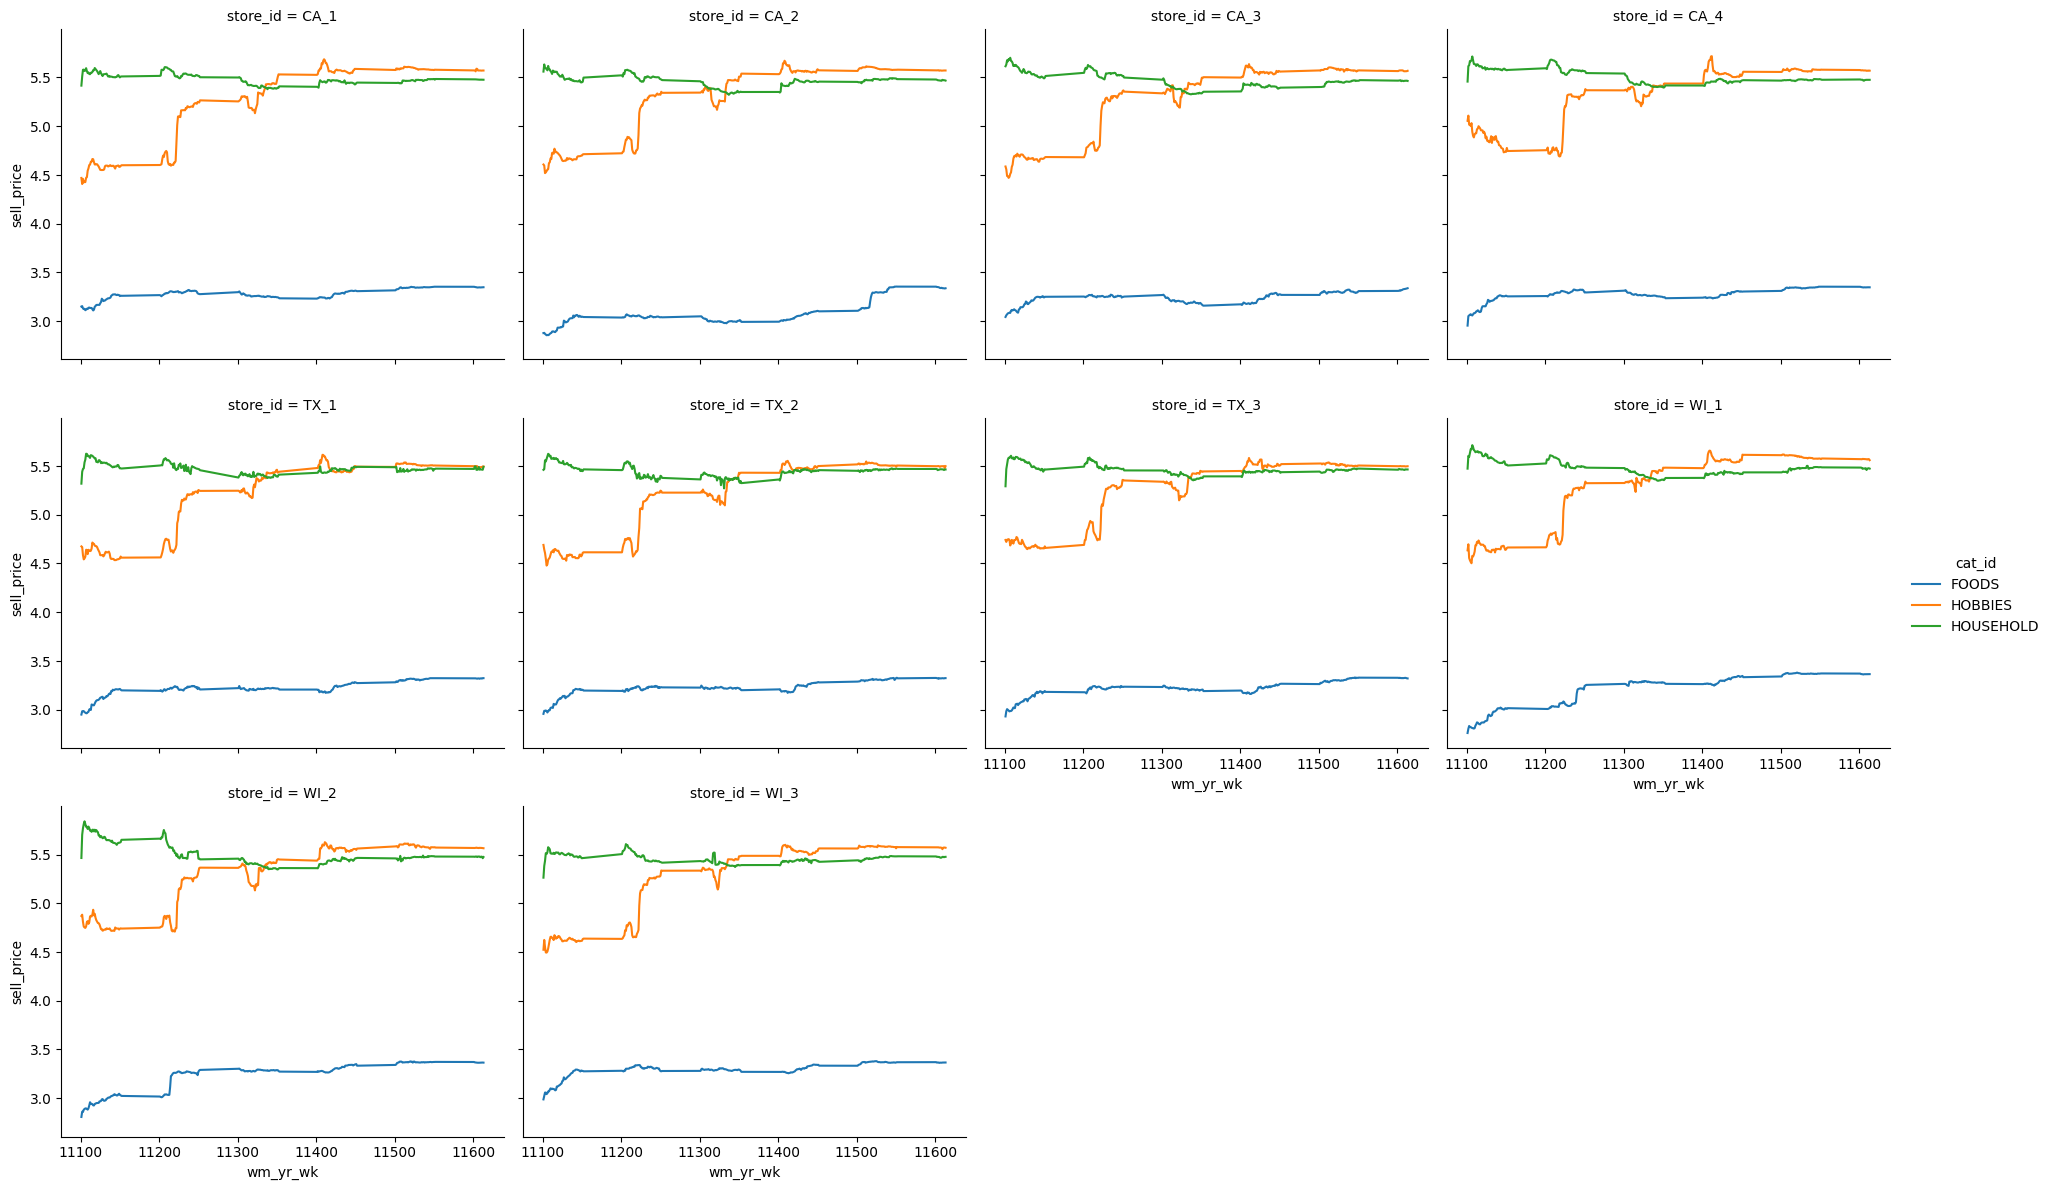

In [64]:
weekly_avg_prices = sales.groupby(['store_id', 'cat_id', 'wm_yr_wk'])['sell_price'].mean().reset_index()
sns.relplot(
    data=weekly_avg_prices,
    x="wm_yr_wk",         # Time axis (weeks)
    y="sell_price",       # Average Price
    hue="cat_id",         # Different color line for each category
    col="store_id",       # Separate chart for each store
    col_wrap=4,           # Show 3 charts per row so it fits on screen
    kind="line",          # Use lines to show price trends over time
    height=4,
    aspect=1.2
)
del weekly_avg_prices,sns,plt
gc.collect()
### FOR THE BELOW GRAPH IT IS EVEDENT THAT THE PICE OF ITEMS (FOOD VERY UPWARD MOMENT MOSTLY STAYS NEAR MEAN and HOUSEHOLD LESS DOWNWARD MOMENT AND ALSO MOSTLY AROUND THE MEAN
#  BUT THE HOBBIES SHOW HUGE UPDAaRD MOMENT WITH LOT OF VARINCE CHANGE ALONG THE DIST)

In [65]:
### WE NEED TO USE USE THE ROLLING MEAN TO COMPUTE THE LONG TERM TREND OF THE ITEM -> FOOD CAT
# WE USE THE LAG FEATURES DIRECTLY TO COMPUTE THE SHORT TERM TREND SAY EVERY AN HUGE TREND ONLY LAST FOR SOME DAYS -> HOUSE HOLD ITEMS 
##EVEN THOUGH THE DATE IS OUTSIDE THE LAG WINDOWS SOME VALUES ARE NONE 
## AS SOME STORES FIRST DAY IS ITSELF THE 8th DAY in global so the nan can extend up to 38 days

In [ ]:
### NEED TO FINDD THE WHEN AN PRODUCT WAS INTRODUCED